# **Proyecto de Modelos**

- Estefania Loaiza Salgado CC 1054857537
- Mariana Vasquez Ramirez CC 1027800363

## **Identificación del sistema respiratorio durante sueño normal**

Se modela la relación dinámica entre el flujo respiratorio, entrada `u(k)`, y el esfuerzo respiratorio, salida `y(k)`, usando el archivo `Exp15.csv`.

## **0. Carga y separación de señales**

Se usan las señales del inicio de la noche para estimación (`t1`, `u1`, `y1`) y las señales de validación (`tv`, `uv`, `yv`) para soportar la elección del modelo.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend, butter, filtfilt, welch

data = pd.read_csv("Exp15.csv", header=None)
datos = data.iloc[1, :].astype(float).values

N = 30720

t1 = datos[0:N]
u1 = datos[N:2*N]
y1 = datos[2*N:3*N]

tv = datos[3*N:4*N]
uv = datos[4*N:5*N]
yv = datos[5*N:6*N]

t2 = datos[6*N:7*N]
u2 = datos[7*N:8*N]
y2 = datos[8*N:9*N]

Ts = np.mean(np.diff(t1))
fs = 1 / Ts

print("Ts =", Ts)
print("fs =", fs)
print("Muestras por segmento =", N)

Ts = 0.0009765625
fs = 1024.0
Muestras por segmento = 30720


## **1. Inspección inicial de las señales**

La respiración normal durante el sueño es principalmente periódica y de baja frecuencia. Se inspeccionan las señales antes del preprocesamiento.

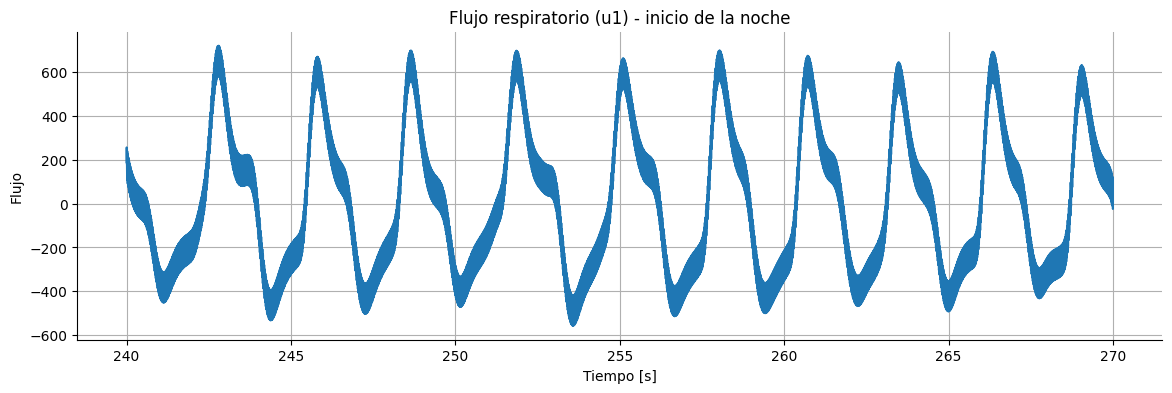

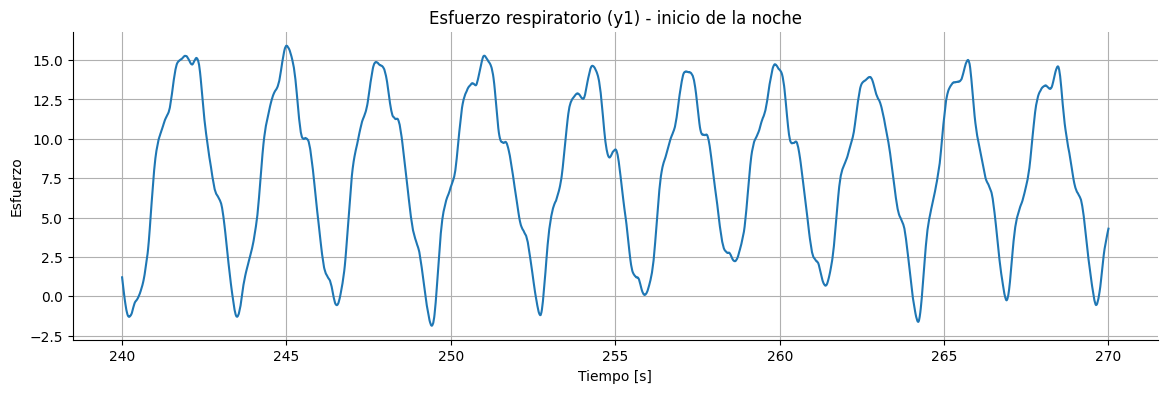

In [34]:
plt.figure(figsize=(14, 4))
plt.plot(t1, u1)
plt.title("Flujo respiratorio (u1) - inicio de la noche")
plt.xlabel("Tiempo [s]")
plt.ylabel("Flujo")
plt.grid()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(t1, y1)
plt.title("Esfuerzo respiratorio (y1) - inicio de la noche")
plt.xlabel("Tiempo [s]")
plt.ylabel("Esfuerzo")
plt.grid()
plt.show()

**Observaciones**

- El flujo `u1` y el esfuerzo `y1` son señales periódicas respiratorias claras.
- El esfuerzo presenta un ligero retardo respecto al flujo (esperable fisiológicamente).
- No se observan saturaciones ni discontinuidades.
- La frecuencia respiratoria es cercana a 0.3–0.4 Hz.

## **2. Preprocesamiento**

Se aplica el preprocesamiento requerido en la **consideración a)**:

- **Detrend:** elimina tendencias lentas no asociadas con la dinámica respiratoria local.
- **Filtrado pasa bajas:** `fc = 3 Hz`, para conservar la banda respiratoria dominante (justificado con la PSD).
- **Submuestreo:** se reduce la frecuencia de muestreo de `1024 Hz` a `32 Hz` usando `factor = 32`. Esta frecuencia sigue siendo mayor que el doble de la frecuencia de corte y evita que la predicción sea trivial por sobremuestreo.
- **Normalización:** con media y desviación estándar del conjunto de estimación; la misma escala se aplica a validación.

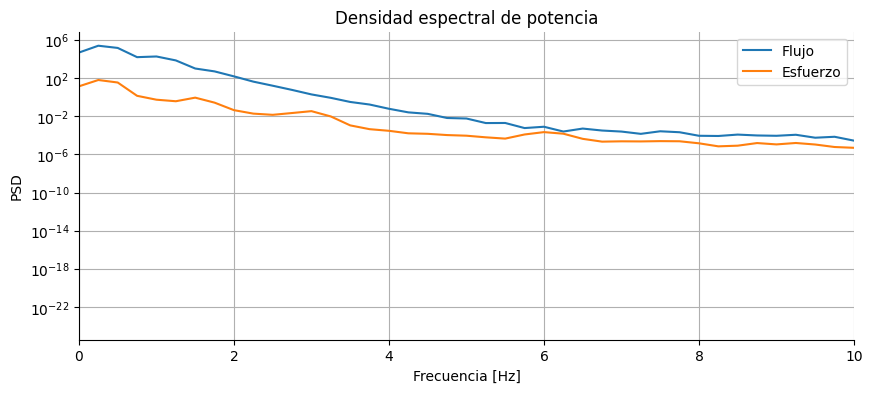

In [35]:
# Detrend
u1_d = detrend(u1)
y1_d = detrend(y1)
uv_d = detrend(uv)
yv_d = detrend(yv)

# Densidad espectral para justificar el filtrado
f_u, P_u = welch(u1_d, fs, nperseg=4096)
f_y, P_y = welch(y1_d, fs, nperseg=4096)

plt.figure(figsize=(10, 4))
plt.semilogy(f_u, P_u, label="Flujo")
plt.semilogy(f_y, P_y, label="Esfuerzo")
plt.xlim([0, 10])
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD")
plt.title("Densidad espectral de potencia")
plt.grid()
plt.legend()
plt.show()

In [36]:
# Filtrado pasa bajas
fc = 3
b_f, a_f = butter(4, fc / (fs / 2), btype="low")

u1_f = filtfilt(b_f, a_f, u1_d)
y1_f = filtfilt(b_f, a_f, y1_d)
uv_f = filtfilt(b_f, a_f, uv_d)
yv_f = filtfilt(b_f, a_f, yv_d)

# Submuestreo
factor = 32
u1_s = u1_f[::factor]
y1_s = y1_f[::factor]
uv_s = uv_f[::factor]
yv_s = yv_f[::factor]
fs_new = fs / factor

# Normalizacion con estadisticos del conjunto de estimacion
u_mean, u_std = np.mean(u1_s), np.std(u1_s)
y_mean, y_std = np.mean(y1_s), np.std(y1_s)

u1_n = (u1_s - u_mean) / u_std
y1_n = (y1_s - y_mean) / y_std
uv_n = (uv_s - u_mean) / u_std
yv_n = (yv_s - y_mean) / y_std

print("Nueva frecuencia de muestreo =", fs_new, "Hz")
print("Muestras estimacion =", len(u1_n))
print("Muestras validacion =", len(uv_n))

Nueva frecuencia de muestreo = 128.0 Hz
Muestras estimacion = 3840
Muestras validacion = 3840


# **Actividad 1. Identificación del sistema usando técnicas paramétricas**

Se estiman los modelos usando las señales del inicio de la noche (`u1_n`, `y1_n`) y se validan con (`uv_n`, `yv_n`).

Estructuras consideradas:

$$A(q)\,y(k)=e(k) \qquad \text{AR}$$

$$A(q)\,y(k)=B(q)\,u(k)+e(k) \qquad \text{ARX}$$

$$A(q)\,y(k)=C(q)\,e(k) \qquad \text{ARMA}$$

$$A(q)\,y(k)=B(q)\,u(k)+C(q)\,e(k) \qquad \text{ARMAX}$$

$$y(k)=\dfrac{B(q)}{F(q)}\,u(k)+e(k) \qquad \text{OE}$$

$$y(k)=\dfrac{B(q)}{F(q)}\,u(k)+\dfrac{C(q)}{D(q)}\,e(k) \qquad \text{BJ}$$

con

$$A(q)=1+a_1 q^{-1}+\cdots+a_{n_a} q^{-n_a}, \qquad B(q)=b_1 q^{-n_k}+\cdots+b_{n_b} q^{-(n_k+n_b-1)}$$

**Consideración b)** Se eligen órdenes con más de 4 parámetros. Para las estructuras con entrada se usan 6 retardos de salida y 6 de entrada.

## **Funciones auxiliares de identificación**

Funciones para construir regresores, estimar por mínimos cuadrados, predecir (un paso) y simular (salida libre), con las métricas `Fit [%]` y `RMSE`.

In [37]:
def fit_porcentaje(y_real, y_est):
    y_real = np.asarray(y_real).ravel()
    y_est = np.asarray(y_est).ravel()
    mask = np.isfinite(y_est)
    y_real = y_real[mask]
    y_est = y_est[mask]
    return 100 * (1 - np.linalg.norm(y_real - y_est) / np.linalg.norm(y_real - np.mean(y_real)))


def rmse(y_real, y_est):
    y_real = np.asarray(y_real).ravel()
    y_est = np.asarray(y_est).ravel()
    mask = np.isfinite(y_est)
    return np.sqrt(np.mean((y_real[mask] - y_est[mask]) ** 2))


def matriz_regresion(y, u, na, nb, nk, nc=0, e=None):
    inicio = max(na, nb + nk - 1 if nb > 0 else 0, nc)
    Phi, Y = [], []
    for k in range(inicio, len(y)):
        fila = []
        for i in range(1, na + 1):
            fila.append(-y[k - i])
        for j in range(nb):
            fila.append(u[k - nk - j])
        if nc > 0 and e is not None:
            for i in range(1, nc + 1):
                fila.append(e[k - i])
        Phi.append(fila)
        Y.append(y[k])
    return np.asarray(Phi), np.asarray(Y), inicio


def predecir_modelo(y, u, theta, na, nb, nk, nc=0):
    y_est = np.full(len(y), np.nan)
    if nc > 0:
        theta_base = theta[:na + nb]
        y_base = predecir_modelo(y, u, theta_base, na, nb, nk, 0)
        e = y - y_base
        e[~np.isfinite(e)] = 0
    else:
        e = None
    _, _, inicio = matriz_regresion(y, u, na, nb, nk, nc, e)
    for k in range(inicio, len(y)):
        fila = []
        for i in range(1, na + 1):
            fila.append(-y[k - i])
        for j in range(nb):
            fila.append(u[k - nk - j])
        if nc > 0:
            for i in range(1, nc + 1):
                fila.append(e[k - i])
        y_est[k] = np.dot(fila, theta)
    return y_est


def estimar_modelo(y, u, na, nb, nk, nc=0):
    Phi, Y, _ = matriz_regresion(y, u, na, nb, nk)
    theta_base = np.linalg.lstsq(Phi, Y, rcond=None)[0]
    if nc == 0:
        return theta_base
    y_base = predecir_modelo(y, u, theta_base, na, nb, nk, 0)
    e_base = y - y_base
    e_base[~np.isfinite(e_base)] = 0
    Phi, Y, _ = matriz_regresion(y, u, na, nb, nk, nc, e_base)
    return np.linalg.lstsq(Phi, Y, rcond=None)[0]


def simular_modelo(u, y_inicial, theta, na, nb, nk):
    y_sim = np.zeros(len(u))
    inicio = max(na, nb + nk - 1 if nb > 0 else 0)
    y_sim[:inicio] = y_inicial[:inicio]
    for k in range(inicio, len(u)):
        fila = []
        for i in range(1, na + 1):
            fila.append(-y_sim[k - i])
        for j in range(nb):
            fila.append(u[k - nk - j])
        y_sim[k] = np.dot(fila, theta[:na + nb])
    return y_sim

## **Estimación y validación de todas las estructuras**

Cada estructura se estima con los datos del inicio de la noche y se evalúa sobre las señales de validación, comparando `Fit [%]` y `RMSE`.

In [ ]:
estructuras = [
    {"Estructura": "AR", "na": 6, "nb": 0, "nk": 1, "nc": 0},
    {"Estructura": "ARX", "na": 6, "nb": 6, "nk": 1, "nc": 0},
    {"Estructura": "ARMA", "na": 6, "nb": 0, "nk": 1, "nc": 3},
    {"Estructura": "ARMAX", "na": 6, "nb": 6, "nk": 1, "nc": 3},
    {"Estructura": "OE", "na": 6, "nb": 6, "nk": 1, "nc": 0},
    {"Estructura": "BJ", "na": 6, "nb": 6, "nk": 1, "nc": 3},
]

resultados = []
modelos_estimados = {}

for cfg in estructuras:
    nombre, na, nb, nk, nc = cfg["Estructura"], cfg["na"], cfg["nb"], cfg["nk"], cfg["nc"]

    u_est = np.zeros_like(u1_n) if nb == 0 else u1_n
    u_val = np.zeros_like(uv_n) if nb == 0 else uv_n

    theta = estimar_modelo(y1_n, u_est, na, nb, nk, nc)
    y_pred_val = predecir_modelo(yv_n, u_val, theta, na, nb, nk, nc)
    y_sim_val = simular_modelo(u_val, yv_n, theta, na, nb, nk)

    resultados.append({
        "Estructura": nombre,
        "Orden": f"na={na}, nb={nb}, nk={nk}, nc={nc}",
        "Parametros": len(theta),
        "Tiene entrada": nb > 0,
        "Fit prediccion [%]": fit_porcentaje(yv_n, y_pred_val),
        "Fit simulacion [%]": fit_porcentaje(yv_n, y_sim_val),
        "RMSE prediccion": rmse(yv_n, y_pred_val),
        "RMSE simulacion": rmse(yv_n, y_sim_val),
    })

    modelos_estimados[nombre] = {
        "theta": theta,
        "na": na,
        "nb": nb,
        "nk": nk,
        "nc": nc,
        "u_val": u_val,
        "y_pred_val": y_pred_val,
        "y_sim_val": y_sim_val,
    }

resultados_df = pd.DataFrame(resultados)

# Para describir la relacion flujo-esfuerzo se priorizan modelos con entrada.
# La seleccion se hace principalmente por simulacion libre en validacion,
# porque esta metrica evalua mejor la dinamica entrada-salida.
candidatos = resultados_df[resultados_df["Tiene entrada"]].copy()
candidatos = candidatos.sort_values(
    ["Fit simulacion [%]", "RMSE simulacion", "Fit prediccion [%]"],
    ascending=[False, True, False]
).reset_index(drop=True)

resultados_df = resultados_df.sort_values(
    ["Tiene entrada", "Fit simulacion [%]", "RMSE simulacion", "Fit prediccion [%]"],
    ascending=[False, False, True, False]
).reset_index(drop=True)

print("Comparacion de todas las estructuras:")
display(resultados_df)

print("Candidatos con entrada usados para seleccionar el modelo flujo-esfuerzo:")
display(candidatos)

,Estructura,Orden,Parametros,Fit prediccion [%],Fit simulacion [%],RMSE prediccion,RMSE simulacion
0,BJ,"na=6, nb=6, nk=1, nc=3",15,100.000000,-279.745264,1.178751e-09,3.752793
1,ARMAX,"na=6, nb=6, nk=1, nc=3",15,100.000000,-279.745264,1.178751e-09,3.752793
2,ARMA,"na=6, nb=0, nk=1, nc=3",9,100.000000,5.861754,1.401916e-09,0.930311
3,AR,"na=6, nb=0, nk=1, nc=0",6,99.999998,6.750671,2.423962e-08,0.921527
4,ARX,"na=6, nb=6, nk=1, nc=0",12,99.999997,-181.461758,2.617075e-08,2.781517
5,OE,"na=6, nb=6, nk=1, nc=0",12,99.999997,-181.461758,2.617075e-08,2.781517


Estructura seleccionada: BJ
Orden seleccionado: na=6, nb=6, nk=1, nc=3
Numero de parametros: 15


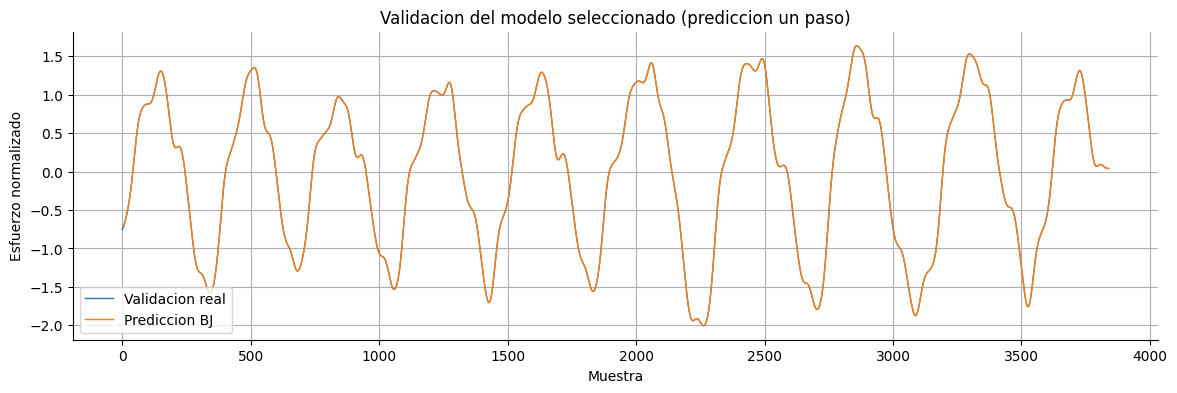

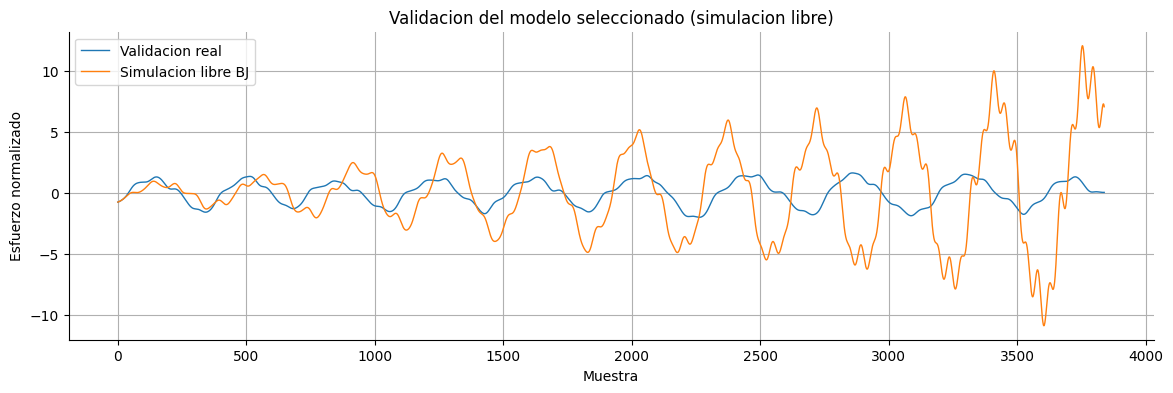

In [ ]:
mejor_estructura = candidatos.iloc[0]["Estructura"]
modelo_final = modelos_estimados[mejor_estructura]

print("Estructura seleccionada:", mejor_estructura)
print("Orden seleccionado:", candidatos.iloc[0]["Orden"])
print("Numero de parametros:", candidatos.iloc[0]["Parametros"])
print("Fit prediccion [%]:", candidatos.iloc[0]["Fit prediccion [%]"])
print("RMSE prediccion:", candidatos.iloc[0]["RMSE prediccion"])
print("Fit simulacion [%]:", candidatos.iloc[0]["Fit simulacion [%]"])
print("RMSE simulacion:", candidatos.iloc[0]["RMSE simulacion"])

plt.figure(figsize=(14, 4))
plt.plot(yv_n, label="Validacion real", linewidth=1)
plt.plot(modelo_final["y_pred_val"], label=f"Prediccion {mejor_estructura}", linewidth=1)
plt.title("Validacion del modelo seleccionado (prediccion un paso)")
plt.xlabel("Muestra")
plt.ylabel("Esfuerzo normalizado")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(yv_n, label="Validacion real", linewidth=1)
plt.plot(modelo_final["y_sim_val"], label=f"Simulacion libre {mejor_estructura}", linewidth=1)
plt.title("Validacion del modelo seleccionado (simulacion libre)")
plt.xlabel("Muestra")
plt.ylabel("Esfuerzo normalizado")
plt.grid()
plt.legend()
plt.show()

## **C. Ecuación final del modelo**

Se presenta el modelo seleccionado con sus coeficientes numéricos y su ecuación en diferencias, que describe la relación entre el flujo `u(k)` y el esfuerzo `y(k)` al inicio de la noche.

In [40]:
theta = modelo_final["theta"]
na, nb, nk = modelo_final["na"], modelo_final["nb"], modelo_final["nk"]

a_coef = theta[:na]
b_coef = theta[na:na + nb]

Aq = "1 " + " ".join([f"{a:+.6f} q^-{i}" for i, a in enumerate(a_coef, start=1)])
Bq = " ".join([f"{b:+.6f} q^-{nk + j}" for j, b in enumerate(b_coef)]) if nb > 0 else "0"

ecuacion_y = " ".join([f"{-a_coef[i - 1]:+.6f} y(k-{i})" for i in range(1, na + 1)])
ecuacion_u = " ".join([f"{b_coef[j]:+.6f} u(k-{nk + j})" for j in range(nb)])

print("Estructura seleccionada:", mejor_estructura)
print()
print("Modelo final (datos normalizados):")
print("A(q) y(k) = B(q) u(k) + e(k)")
print("A(q) =", Aq)
print("B(q) =", Bq)
print()
print("Ecuacion en diferencias:")
print("y(k) =", ecuacion_y, ecuacion_u, "+ e(k)")

Estructura seleccionada: BJ

Modelo final (datos normalizados):
A(q) y(k) = B(q) u(k) + e(k)
A(q) = 1 -5.977074 q^-1 +14.912395 q^-2 -19.878649 q^-3 +14.932438 q^-4 -5.993138 q^-5 +1.004029 q^-6
B(q) = -0.017260 q^-1 +0.091842 q^-2 -0.194871 q^-3 +0.206179 q^-4 -0.108815 q^-5 +0.022924 q^-6

Ecuacion en diferencias:
y(k) = +5.977074 y(k-1) -14.912395 y(k-2) +19.878649 y(k-3) -14.932438 y(k-4) +5.993138 y(k-5) -1.004029 y(k-6) -0.017260 u(k-1) +0.091842 u(k-2) -0.194871 u(k-3) +0.206179 u(k-4) -0.108815 u(k-5) +0.022924 u(k-6) + e(k)


## **Justificación de la selección**

La estructura se selecciona usando las señales de validación, pero priorizando los modelos que contienen entrada (`u(k)`), porque el objetivo del proyecto es describir la relación entre el flujo respiratorio y el esfuerzo respiratorio.

Aunque los modelos AR y ARMA pueden alcanzar buen desempeño en predicción de un paso, estos modelos dependen únicamente de valores pasados de la salida y no describen explícitamente la relación flujo-esfuerzo. Por esta razón, la comparación final se realiza entre ARX, ARMAX, OE y BJ.

La métrica principal de selección es el `Fit simulación [%]` junto con el `RMSE simulación`, porque la simulación libre evalúa mejor la dinámica entrada-salida del modelo en validación. También se reporta la predicción de un paso como soporte adicional.

El orden seleccionado cumple la **consideración b)** porque tiene más de 4 parámetros. Además, los retardos incluidos permiten capturar la memoria del sistema respiratorio y el desfase fisiológico entre el flujo y el esfuerzo al inicio de la noche.

# **Actividad 2. Análisis de sensibilidad**

Sobre el modelo final se analiza la sensibilidad de sus parámetros. Cada parámetro se perturba un 1% y se mide el cambio relativo que produce en la salida estimada durante validación:

$$
S_i = \frac{\lVert \hat{y}_{\theta_i + \Delta\theta_i} - \hat{y}_{\theta} \rVert_2}{\lVert \hat{y}_{\theta} \rVert_2}\,\frac{1}{\Delta}
$$

Los parámetros con mayor `S_i` son los más influyentes en la dinámica entrada-salida.

In [42]:
def nombres_parametros(na, nb, nk, nc):
    nombres = []
    for i in range(1, na + 1):
        nombres.append(f"a{i}")
    for j in range(nb):
        nombres.append(f"b{j + 1} (q^-{nk + j})")
    for i in range(1, nc + 1):
        nombres.append(f"c{i}")
    return nombres


def salida_sensibilidad(theta_eval):
    return predecir_modelo(
        yv_n, modelo_final["u_val"], theta_eval,
        modelo_final["na"], modelo_final["nb"], modelo_final["nk"], modelo_final["nc"],
    )


theta0 = modelo_final["theta"].copy()
y_base = salida_sensibilidad(theta0)
mask = np.isfinite(y_base)
perturbacion = 0.01
nombres = nombres_parametros(modelo_final["na"], modelo_final["nb"], modelo_final["nk"], modelo_final["nc"])

sensibilidades = []
for i in range(len(theta0)):
    theta_p = theta0.copy()
    delta = perturbacion * abs(theta0[i]) if abs(theta0[i]) > 1e-8 else perturbacion
    theta_p[i] += delta
    y_p = salida_sensibilidad(theta_p)
    s = (np.linalg.norm(y_p[mask] - y_base[mask]) / np.linalg.norm(y_base[mask])) / perturbacion
    sensibilidades.append({"Parametro": nombres[i], "Valor": theta0[i], "Sensibilidad": s})

sensibilidad_df = pd.DataFrame(sensibilidades).sort_values("Sensibilidad", ascending=False).reset_index(drop=True)
sensibilidad_df

,Parametro,Valor,Sensibilidad
0,a3,-19.878649,7.197168e-01
1,a4,14.932438,5.421055e-01
2,a2,14.912395,5.383650e-01
3,a5,-5.993138,2.181301e-01
4,a1,-5.977074,2.151340e-01
5,a6,1.004029,3.663053e-02
6,b4 (q^-4),0.206179,6.243446e-03
7,b3 (q^-3),-0.194871,5.893906e-03
8,b5 (q^-5),-0.108815,3.300257e-03
9,b2 (q^-2),0.091842,2.775623e-03


,Parametro,Valor,Sensibilidad
0,a3,-19.878649,0.719717
1,a4,14.932438,0.542105
2,a2,14.912395,0.538365
3,a5,-5.993138,0.218130


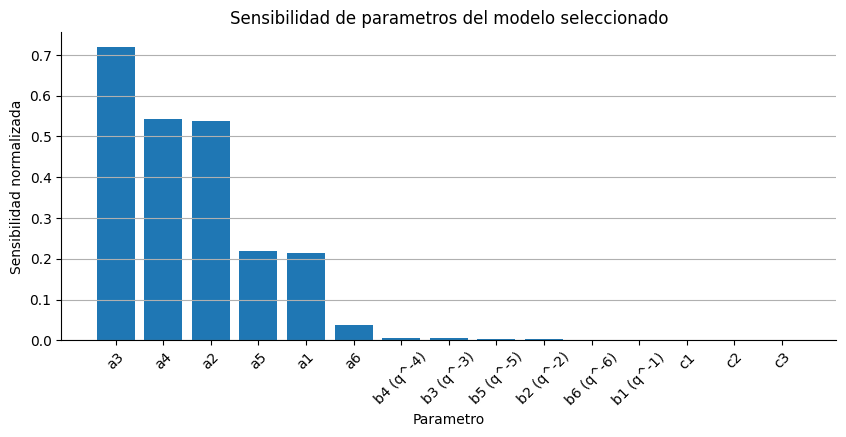

Los 4 parametros mas sensibles son:
a3: sensibilidad = 0.719717, valor = -19.878649
a4: sensibilidad = 0.542105, valor = 14.932438
a2: sensibilidad = 0.538365, valor = 14.912395
a5: sensibilidad = 0.218130, valor = -5.993138


In [43]:
top4_sensibles = sensibilidad_df.head(4)
display(top4_sensibles)

plt.figure(figsize=(10, 4))
plt.bar(sensibilidad_df["Parametro"], sensibilidad_df["Sensibilidad"])
plt.title("Sensibilidad de parametros del modelo seleccionado")
plt.xlabel("Parametro")
plt.ylabel("Sensibilidad normalizada")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

print("Los 4 parametros mas sensibles son:")
for _, fila in top4_sensibles.iterrows():
    print(f"{fila['Parametro']}: sensibilidad = {fila['Sensibilidad']:.6f}, valor = {fila['Valor']:.6f}")

## **Justificación de los 4 parámetros más sensibles**

Los cuatro parámetros seleccionados son los de mayor sensibilidad normalizada: pequeñas variaciones en ellos producen los mayores cambios en la salida estimada del esfuerzo respiratorio durante validación.

Por tanto, son los parámetros más influyentes del modelo final y deben estimarse con mayor cuidado, ya que errores en ellos afectan más la descripción de la relación entre flujo y esfuerzo. Los parámetros restantes tienen menor impacto, lo que indica que el modelo podría incluso simplificarse sin perder mucha precisión.